# Problem 2.19: Recursive Digital Reverberation / Echo

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
A recursive implementation of reverberation is given by (2.103):
$$
y[n] = x[n] + a y[n - D]
$$
where $D = \tau F_s$ is the delay in sampling intervals given delay $\tau$ in seconds and sampling rate $F_s$, and $a$ is an attenuation factor. To generate digital reverberation we use the sound file `handel` recorded at $F_s = 8192$ samples per second.

* **(a)** For $\tau = 50\text{ ms}$ and $a = 0.7$, obtain a difference equation for the digital reverberation and process the sound in `handel`. Comment on its audio quality.
* **(b)** Repeat (a) for $\tau = 100\text{ ms}$.
* **(c)** Repeat (a) for $\tau = 500\text{ ms}$.
* **(d)** Which implementation sounds natural?

In [1]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Audio, display


## 1. Load Original Audio (`handel.wav`)
Load the original signal $x[n]$ sampled at $F_s = 8192$ Hz.

In [2]:
wav_path = Path('handel.wav')
x, Fs = sf.read(wav_path)

print(f"Sampling rate Fs: {Fs} Hz")
print(f"Total samples: {len(x)}")
print(f"Duration: {len(x) / Fs:.2f} seconds")

print("Original sound:")
display(Audio(data=x, rate=int(Fs)))


Sampling rate Fs: 8192 Hz
Total samples: 73113
Duration: 8.92 seconds
Original sound:


## 2. Recursive Reverberator Function
$$
y[n] = x[n] + a \cdot y[n - D]
$$

In [3]:
def apply_reverberation(x: np.ndarray, Fs: int, tau: float, a: float = 0.7):
    D = round(tau * Fs)
    y = np.zeros_like(x)
    for n in range(len(x)):
        y[n] = x[n]
        if n >= D:
            y[n] += a * y[n - D]
    return y, D


## (a) Reverberation with $\tau = 50\text{ ms}$ and $a = 0.7$
- Delay in samples: $D = 0.05 \times 8192 = 410$ samples ($409.6 \approx 410$).
- **Difference equation:**
  $$
  y[n] = x[n] + 0.7 y[n - 410]
  $$
- **Comment on audio quality:** With a short delay of $50\text{ ms}$, the reflections arrive rapidly within the integration window of human hearing ($< 50\text{ ms}$). Individual echoes blend smoothly together to form a rich, natural acoustic ambience, reminiscent of a concert hall or room reverberation.

In [4]:
tau_a = 0.050  # 50 ms
a = 0.7
y_50, D_a = apply_reverberation(x, Fs, tau_a, a)

print(f"Part (a): tau = {tau_a * 1000:.0f} ms -> D = {D_a} samples")
print(f"Difference equation: y[n] = x[n] + {a} * y[n - {D_a}]")
display(Audio(data=y_50, rate=int(Fs)))

Part (a): tau = 50 ms -> D = 410 samples
Difference equation: y[n] = x[n] + 0.7 * y[n - 410]


## (b) Reverberation with $\tau = 100\text{ ms}$ and $a = 0.7$
- Delay in samples: $D = 0.10 \times 8192 = 819$ samples ($819.2 \approx 819$).
- **Difference equation:**
  $$
  y[n] = x[n] + 0.7 y[n - 819]
  $$
- **Comment on audio quality:** At $100\text{ ms}$, the delay exceeds the human ear's fusion threshold. Discrete repetitions begin to be heard separately as a flutter echo or 'slapback' effect, creating the impression of a very large, cavernous space with distinct echo repetitions.

In [5]:
tau_b = 0.100  # 100 ms
y_100, D_b = apply_reverberation(x, Fs, tau_b, a)

print(f"Part (b): tau = {tau_b * 1000:.0f} ms -> D = {D_b} samples")
print(f"Difference equation: y[n] = x[n] + {a} * y[n - {D_b}]")
display(Audio(data=y_100, rate=int(Fs)))


Part (b): tau = 100 ms -> D = 819 samples
Difference equation: y[n] = x[n] + 0.7 * y[n - 819]


## (c) Reverberation with $\tau = 500\text{ ms}$ and $a = 0.7$
- Delay in samples: $D = 0.50 \times 8192 = 4096$ samples.
- **Difference equation:**
  $$
  y[n] = x[n] + 0.7 y[n - 4096]
  $$
- **Comment on audio quality:** With a delay of half a second ($500\text{ ms}$), the repetitions are clearly separated discrete echoes. The sound resembles shouting in a large canyon or between distant mountains rather than room reverberation.

In [6]:
tau_c = 0.500  # 500 ms
y_500, D_c = apply_reverberation(x, Fs, tau_c, a)

print(f"Part (c): tau = {tau_c * 1000:.0f} ms -> D = {D_c} samples")
print(f"Difference equation: y[n] = x[n] + {a} * y[n - {D_c}]")
display(Audio(data=y_500, rate=int(Fs)))


Part (c): tau = 500 ms -> D = 4096 samples
Difference equation: y[n] = x[n] + 0.7 * y[n - 4096]


## (d) Which implementation sounds natural?

**Answer:** **$\tau = 50\text{ ms}$** Tự nhiên hơn


## Waveform Visualization and Comparison

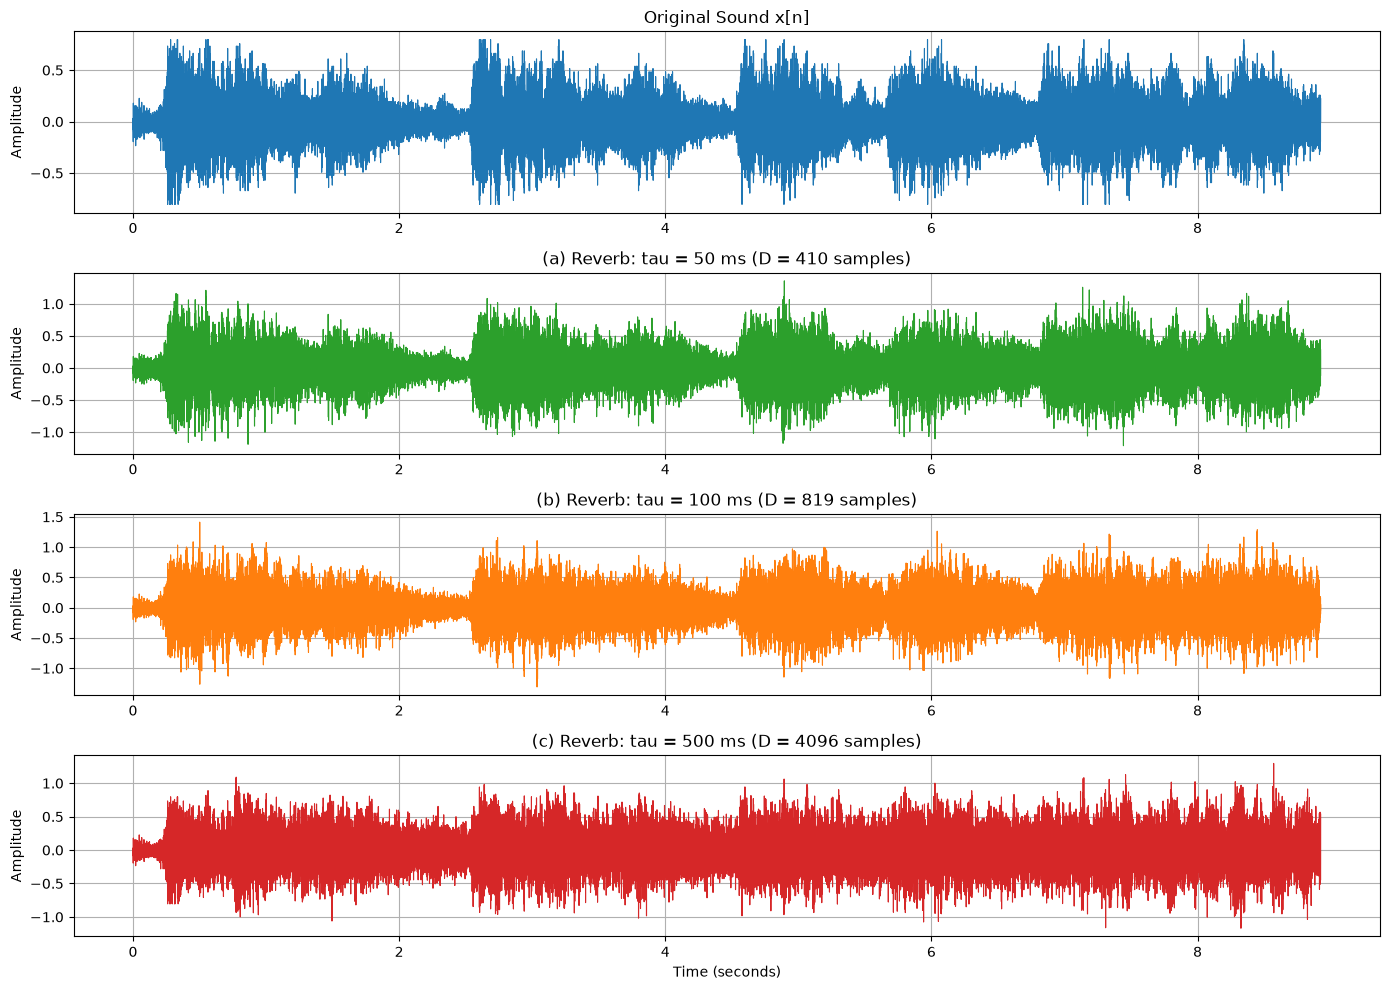

In [7]:
n = np.arange(len(x))
t = n / Fs

plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t, x, color='tab:blue', linewidth=0.8)
plt.title('Original Sound x[n]')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, y_50, color='tab:green', linewidth=0.8)
plt.title(f'(a) Reverb: tau = 50 ms (D = {D_a} samples)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, y_100, color='tab:orange', linewidth=0.8)
plt.title(f'(b) Reverb: tau = 100 ms (D = {D_b} samples)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, y_500, color='tab:red', linewidth=0.8)
plt.title(f'(c) Reverb: tau = 500 ms (D = {D_c} samples)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()
